In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
from google.colab import files
uploaded = files.upload()

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

Saving insurance.csv to insurance.csv


In [36]:
# Load your messy file
df = pd.read_csv('insurance.csv')

# Look at the first 5 rows to see what you are dealing with
print(df.head())
print("Shape:", df.shape)
print("\n--- Info ---")
print(df.info())
print("\n--- Missing Values ---\n", df.isnull().sum())


   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
Shape: (1338, 7)

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

--- Missing Values ---
 age         0
sex         0
bmi    

In [37]:
print("\n--- Numerical Summary ---\n", df.describe().T)
print("\n--- Categorical Summary ---\n", df.describe(include=['O', 'category']).T)


--- Numerical Summary ---
            count          mean           std        min         25%       50%  \
age       1338.0     39.207025     14.049960    18.0000    27.00000    39.000   
bmi       1338.0     30.663397      6.098187    15.9600    26.29625    30.400   
children  1338.0      1.094918      1.205493     0.0000     0.00000     1.000   
charges   1338.0  13270.422265  12110.011237  1121.8739  4740.28715  9382.033   

                   75%          max  
age          51.000000     64.00000  
bmi          34.693750     53.13000  
children      2.000000      5.00000  
charges   16639.912515  63770.42801  

--- Categorical Summary ---
        count unique        top  freq
sex     1338      2       male   676
smoker  1338      2         no  1064
region  1338      4  southeast   364


In [8]:
df.drop_duplicates(inplace=True)
df.dropna( inplace=True)


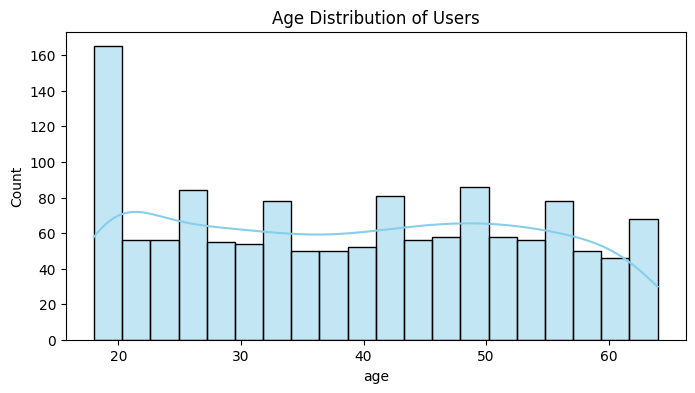

In [11]:
plt.figure(figsize=(8, 4))
sns.histplot(df['age'], bins=20, kde=True, color='skyblue')
plt.title('Age Distribution of Users')
plt.xlabel('age')
plt.ylabel('Count')
plt.show()


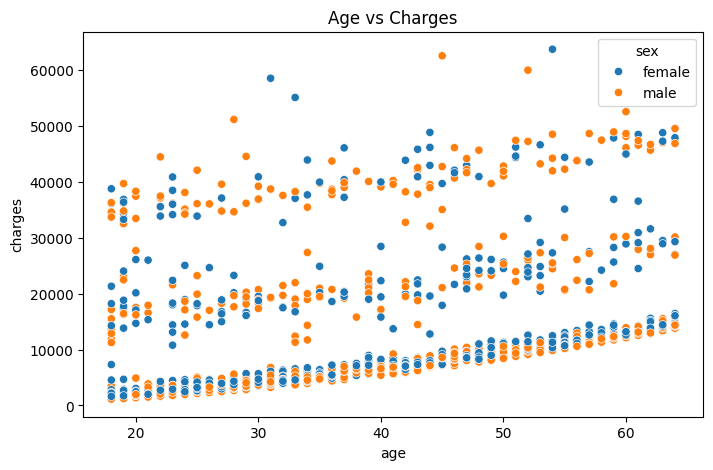

In [13]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='age', y='charges', hue='sex')
plt.title('Age vs Charges')
plt.xlabel('age')
plt.ylabel('charges')
plt.show()


/tmp/ipykernel_646/1839002277.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sex', palette='Set2')


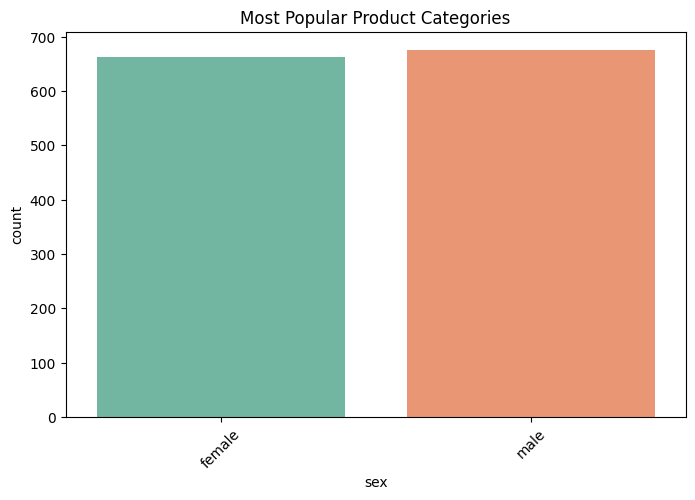

In [14]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='sex', palette='Set2')
plt.title('Most Popular Product Categories')
plt.xticks(rotation=45) # Tilt words so they don't overlap
plt.show()


In [35]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


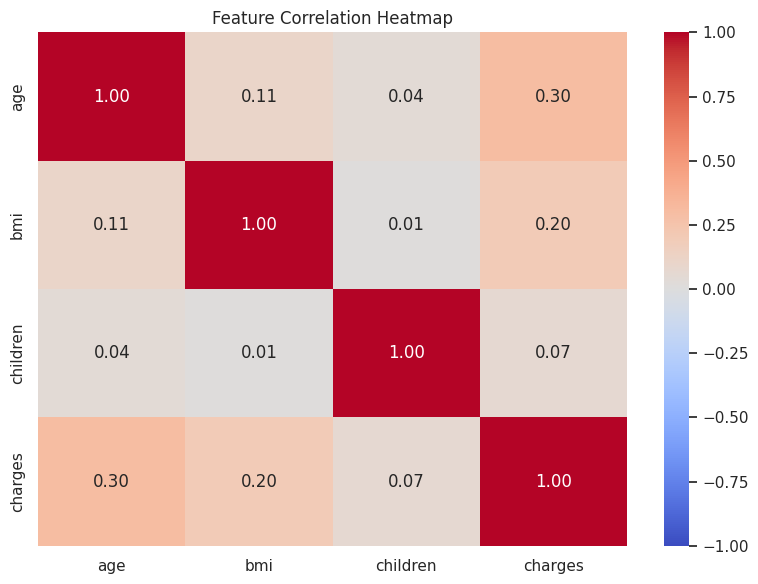

In [38]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr(method="pearson")

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


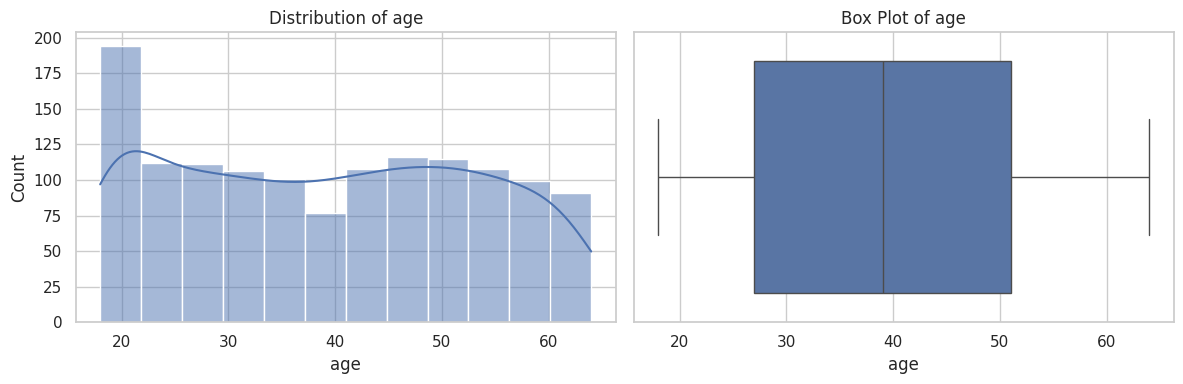

In [39]:
target_col = numeric_df.columns[0]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[target_col], kde=True, ax=axes[0])
axes[0].set_title(f"Distribution of {target_col}")
sns.boxplot(x=df[target_col], ax=axes[1])
axes[1].set_title(f"Box Plot of {target_col}")
plt.tight_layout()
plt.show()

/tmp/ipykernel_646/2012338575.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='region', y='charges', palette='Set2', ax=axes[1, 1])


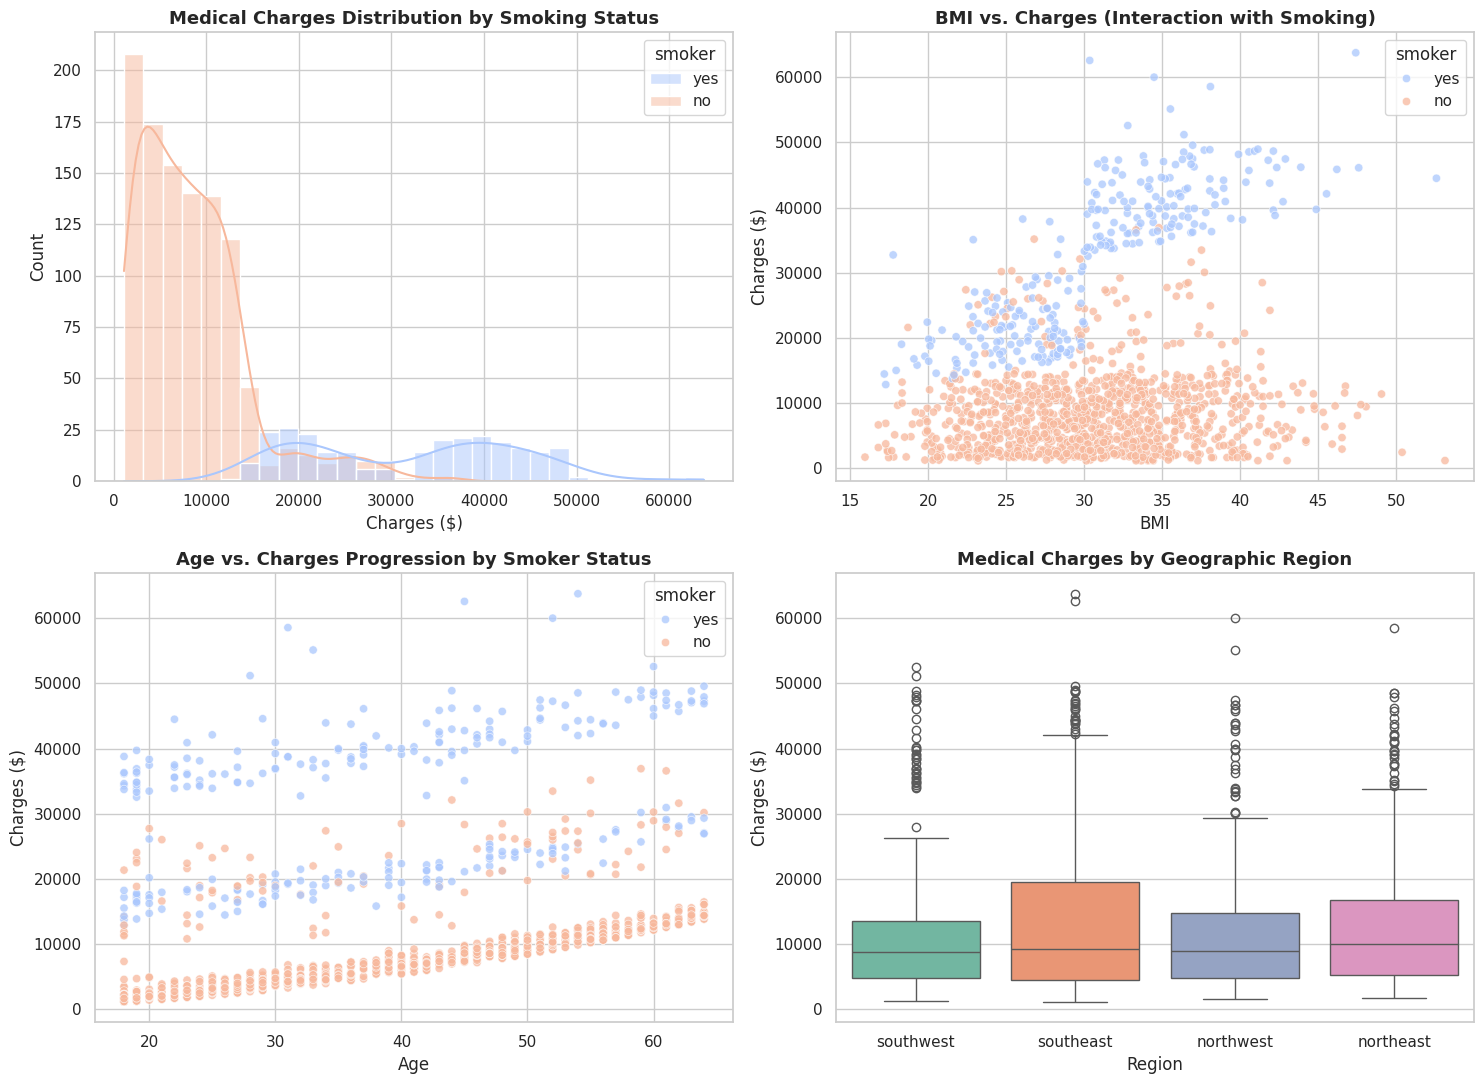

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# 1. Charges distribution segmented by smoker status
sns.histplot(data=df, x='charges', hue='smoker', kde=True, ax=axes[0, 0], palette='coolwarm')
axes[0, 0].set_title('Medical Charges Distribution by Smoking Status', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Charges ($)')

# 2. BMI vs Charges (Non-linear Smoker Interaction)
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', alpha=0.75, ax=axes[0, 1], palette='coolwarm')
axes[0, 1].set_title('BMI vs. Charges (Interaction with Smoking)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('BMI')
axes[0, 1].set_ylabel('Charges ($)')

# 3. Age vs Charges by Smoking Status
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', alpha=0.75, ax=axes[1, 0], palette='coolwarm')
axes[1, 0].set_title('Age vs. Charges Progression by Smoker Status', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Age')
axes[1, 0].set_ylabel('Charges ($)')

# 4. Charges distribution by Region
sns.boxplot(data=df, x='region', y='charges', palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title('Medical Charges by Geographic Region', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Region')
axes[1, 1].set_ylabel('Charges ($)')

plt.tight_layout()
plt.show()

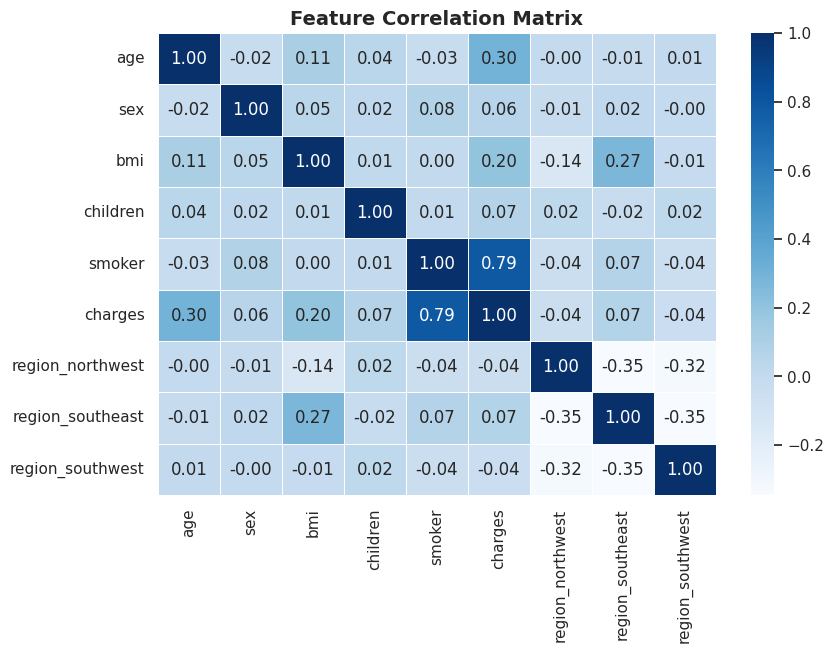

In [41]:
# Preprocess categorical features for correlation calculation
df_corr = df.copy()
df_corr['smoker'] = (df_corr['smoker'] == 'yes').astype(int)
df_corr['sex'] = (df_corr['sex'] == 'male').astype(int)
df_corr = pd.get_dummies(df_corr, columns=['region'], drop_first=True, dtype=int)

plt.figure(figsize=(9, 6))
sns.heatmap(df_corr.corr(), annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.show()

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MAE ($)': round(mae, 2),
        'RMSE ($)': round(rmse, 2),
        'R² Score': round(r2, 4)
    })

results_df = pd.DataFrame(results)
results_df.sort_values(by='R² Score', ascending=False)

,Model,MAE ($),RMSE ($),R² Score
2,Gradient Boosting Regressor,2517.47,4268.28,0.9009
1,Random Forest Regressor,2637.99,4702.45,0.8797
0,Linear Regression,4177.05,5956.34,0.8069


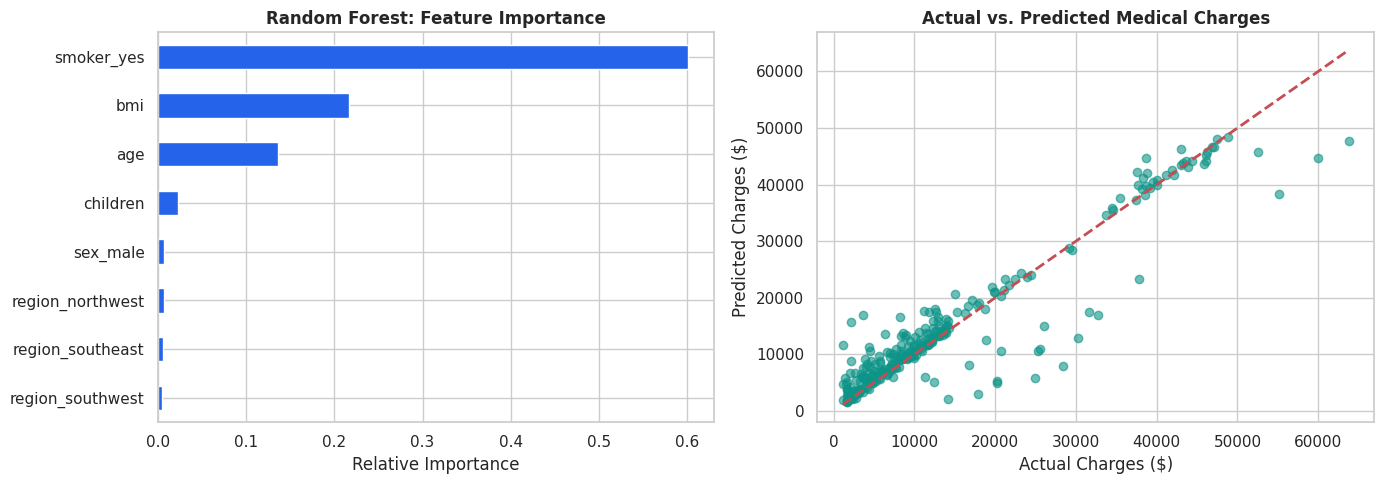

In [44]:
best_rf = models['Random Forest Regressor']
feat_importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature Importance
feat_importances.plot(kind='barh', ax=axes[0], color='#2563EB')
axes[0].set_title('Random Forest: Feature Importance', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Relative Importance')

# Actual vs Predicted Plot
y_test_pred = best_rf.predict(X_test)
axes[1].scatter(y_test, y_test_pred, alpha=0.6, color='#0D9488')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_title('Actual vs. Predicted Medical Charges', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Actual Charges ($)')
axes[1].set_ylabel('Predicted Charges ($)')

plt.tight_layout()
plt.show()